# Part B: Dataset Understanding & Preparation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

plt.style.use('default')

In [2]:
df = pd.read_excel("Message_Intelligence_Dataset_5200.xlsx")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (5200, 16)


,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [4]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   message_id               5200 non-null   int64         
 1   message_text             5200 non-null   object        
 2   message_length           5200 non-null   int64         
 3   word_count               5200 non-null   int64         
 4   num_urls                 5200 non-null   int64         
 5   num_digits               5200 non-null   int64         
 6   num_special_chars        5200 non-null   int64         
 7   spam_keyword_score       5200 non-null   int64         
 8   legit_keyword_score      5200 non-null   int64         
 9   sender_activity_score    5094 non-null   float64       
 10  sender_account_age_days  5087 non-null   float64       
 11  messages_sent_last_24h   5038 non-null   float64       
 12  timestamp                5200 non-

In [5]:
print(df.describe())

          message_id  message_length   word_count     num_urls   num_digits  \
count    5200.000000     5200.000000  5200.000000  5200.000000  5200.000000   
mean   902600.500000       75.035962    11.457308     0.206538     1.681346   
min    900001.000000       32.000000     5.000000     0.000000     0.000000   
25%    901300.750000       67.000000    10.000000     0.000000     0.000000   
50%    902600.500000       74.000000    11.000000     0.000000     0.000000   
75%    903900.250000       81.000000    13.000000     0.000000     4.000000   
max    905200.000000      122.000000    16.000000     1.000000     9.000000   
std      1501.255031       12.455377     1.609056     0.404860     2.415846   

       num_special_chars  spam_keyword_score  legit_keyword_score  \
count        5200.000000         5200.000000          5200.000000   
mean            0.243654            0.246346             0.817692   
min             0.000000            0.000000             0.000000   
25%         

In [6]:
missing_values = df.isnull().sum()

print(missing_values)

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64


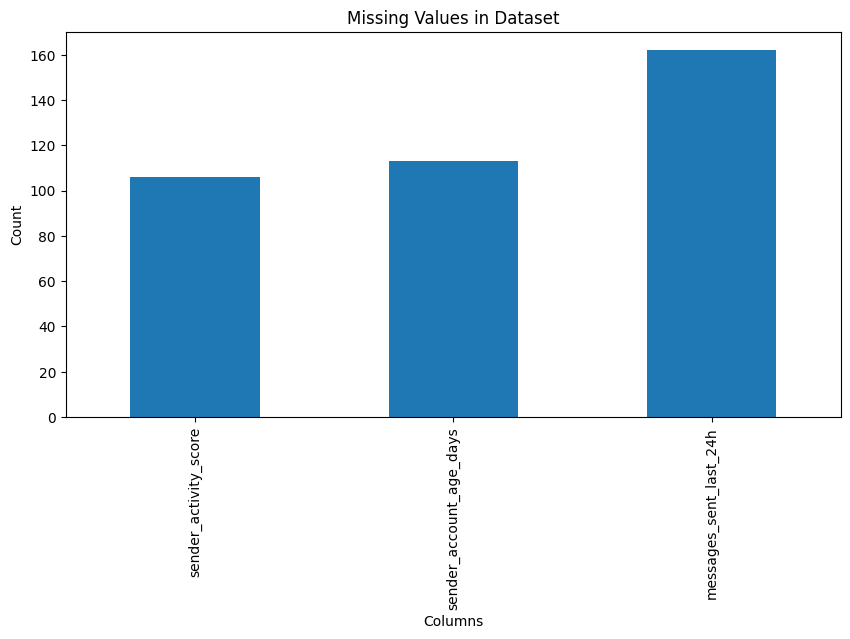

In [7]:
plt.figure(figsize=(10,5))

missing_values[missing_values > 0].plot(
    kind='bar'
)

plt.title("Missing Values in Dataset")
plt.ylabel("Count")
plt.xlabel("Columns")

plt.show()

In [8]:
print(df['spam_label'].value_counts())

spam_label
0    4227
1     973
Name: count, dtype: int64


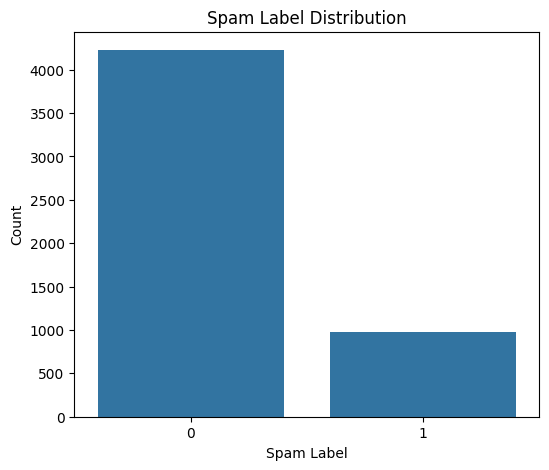

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='spam_label',
    data=df
)

plt.title("Spam Label Distribution")
plt.xlabel("Spam Label")
plt.ylabel("Count")

plt.show()

In [10]:
target = 'spam_label'

drop_cols = []

for col in ['message_id','message_text','timestamp']:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=[target] + drop_cols)

y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

Features:
['message_length', 'word_count', 'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score', 'legit_keyword_score', 'sender_activity_score', 'sender_account_age_days', 'messages_sent_last_24h', 'hour_of_day', 'day_of_week']

Target:
spam_label


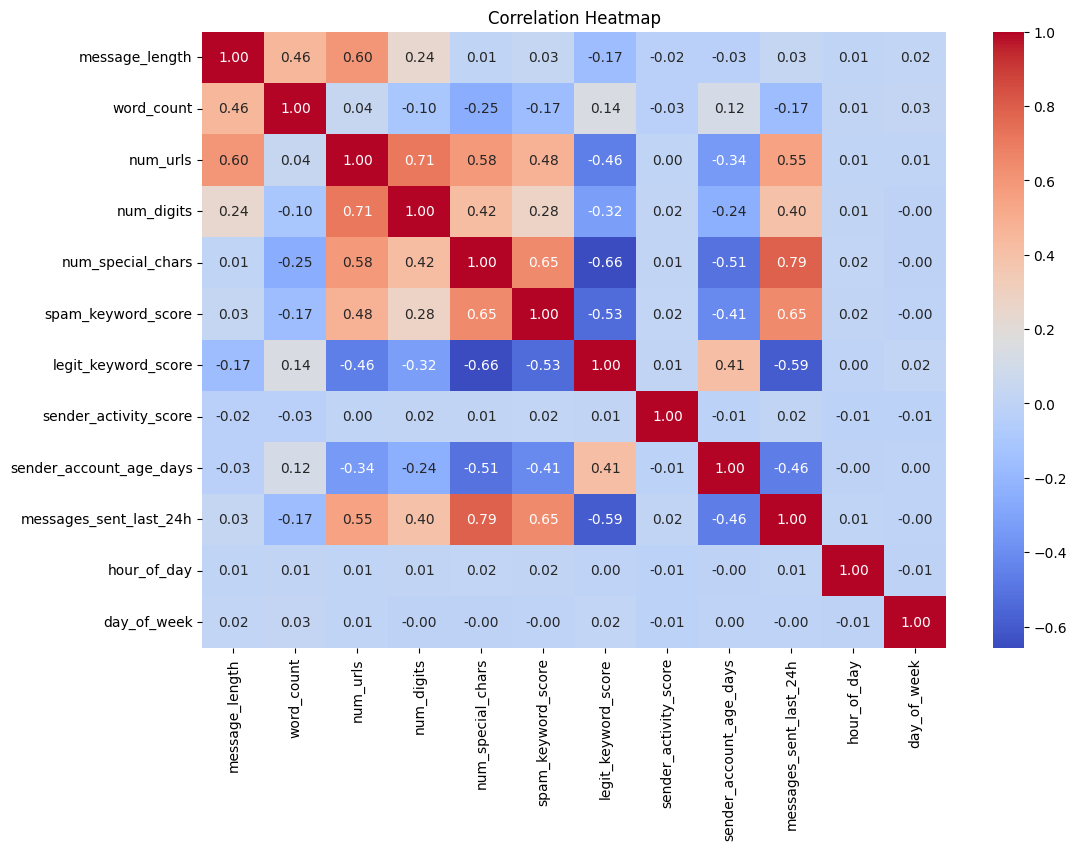

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

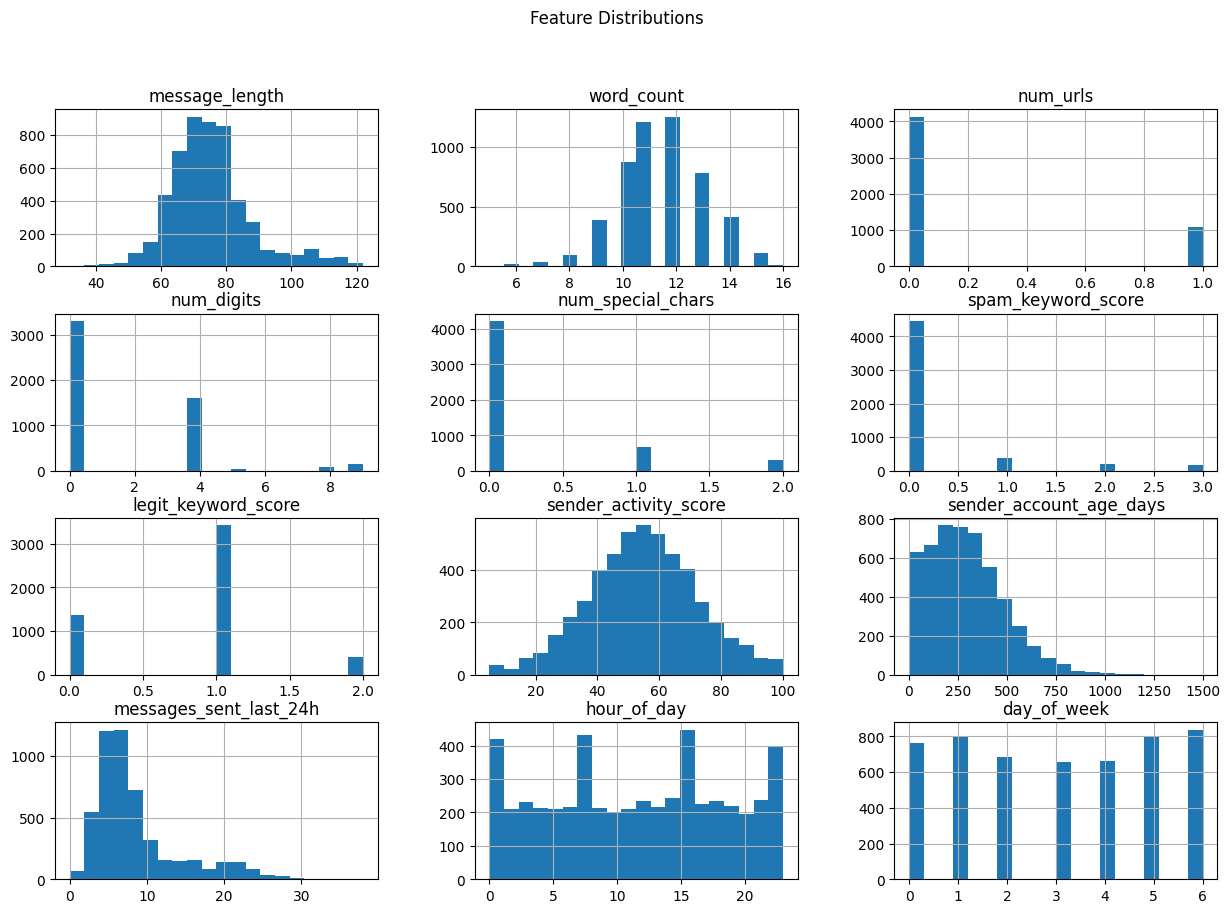

In [12]:
X.hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle("Feature Distributions")

plt.show()

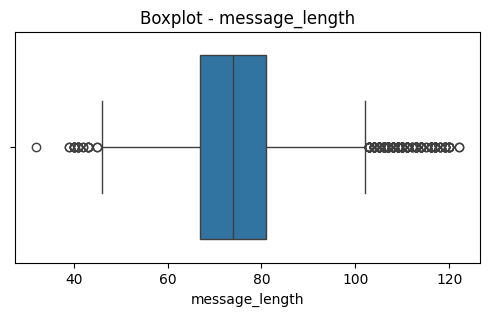

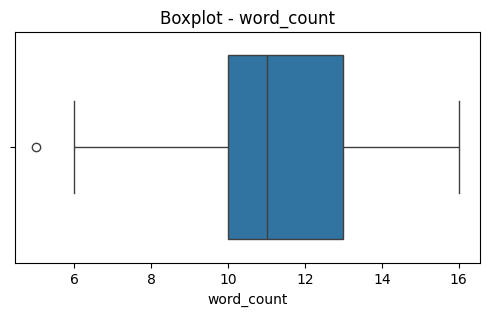

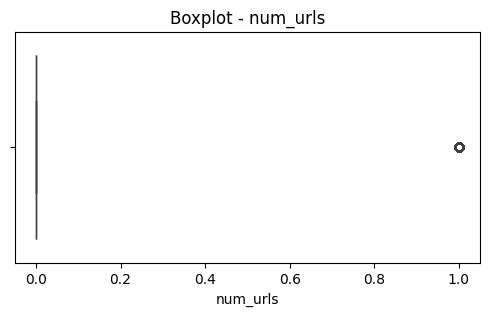

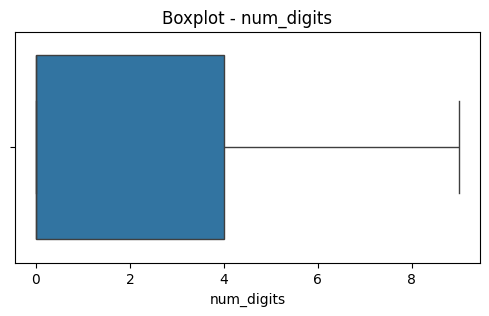

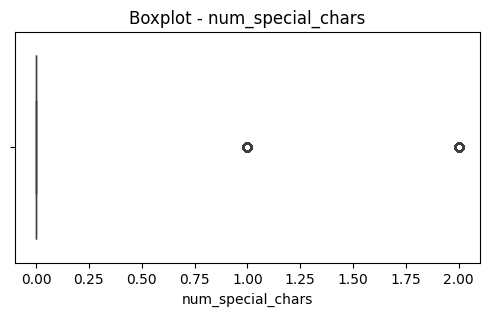

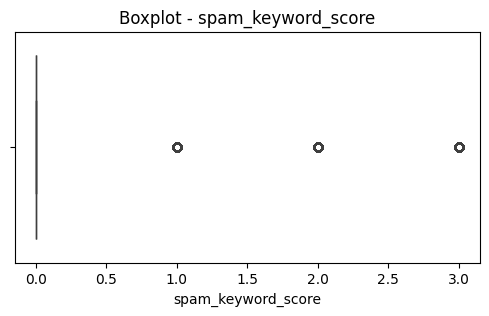

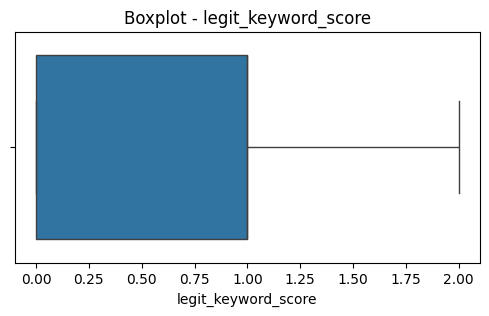

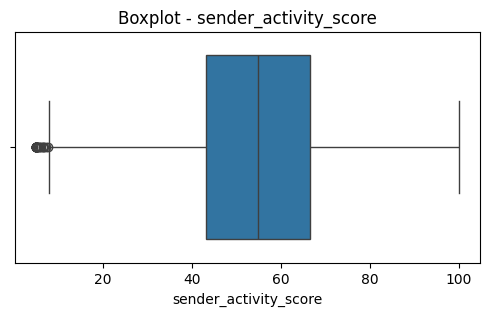

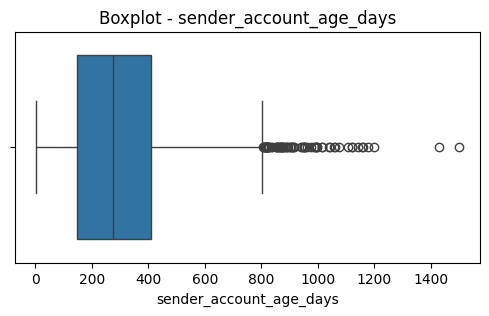

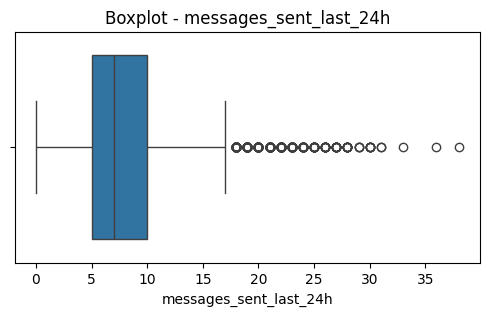

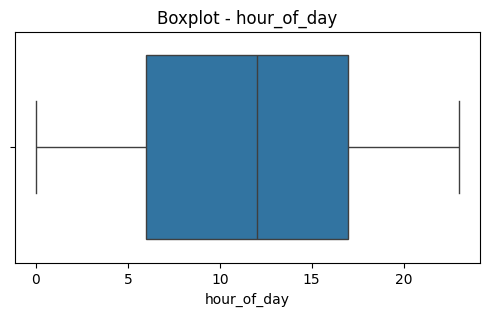

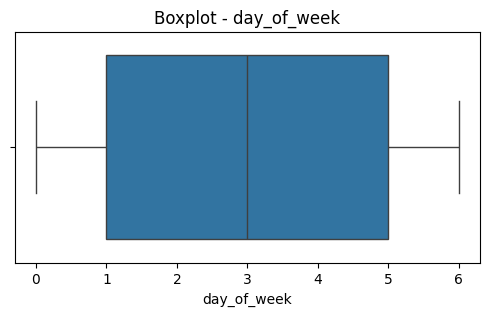

In [13]:
for col in X.columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=X[col]
    )

    plt.title(f"Boxplot - {col}")

    plt.show()

In [14]:
imputer = SimpleImputer(strategy='median')

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print(X_imputed.isnull().sum())

message_length             0
word_count                 0
num_urls                   0
num_digits                 0
num_special_chars          0
spam_keyword_score         0
legit_keyword_score        0
sender_activity_score      0
sender_account_age_days    0
messages_sent_last_24h     0
hour_of_day                0
day_of_week                0
dtype: int64


In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week
0,1.924176,-0.284236,1.960029,0.959861,-0.446817,-0.364023,0.327518,0.100738,1.074541,-0.410937,-1.388086,-1.473518
1,-0.163476,0.337306,-0.510197,-0.696033,-0.446817,-0.364023,-1.468996,-2.183030,-0.470316,-1.501272,1.381247,-0.503730
2,-0.645242,0.958849,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.663473,0.642191,-0.410937,0.215212,0.950952
3,-0.886125,0.958849,-0.510197,0.959861,-0.446817,-0.364023,0.327518,-0.344596,-0.106511,-0.592660,1.672756,-0.503730
4,0.719761,1.580391,-0.510197,-0.696033,-0.446817,-0.364023,0.327518,-1.246685,2.039417,-0.229215,-0.076297,0.950952


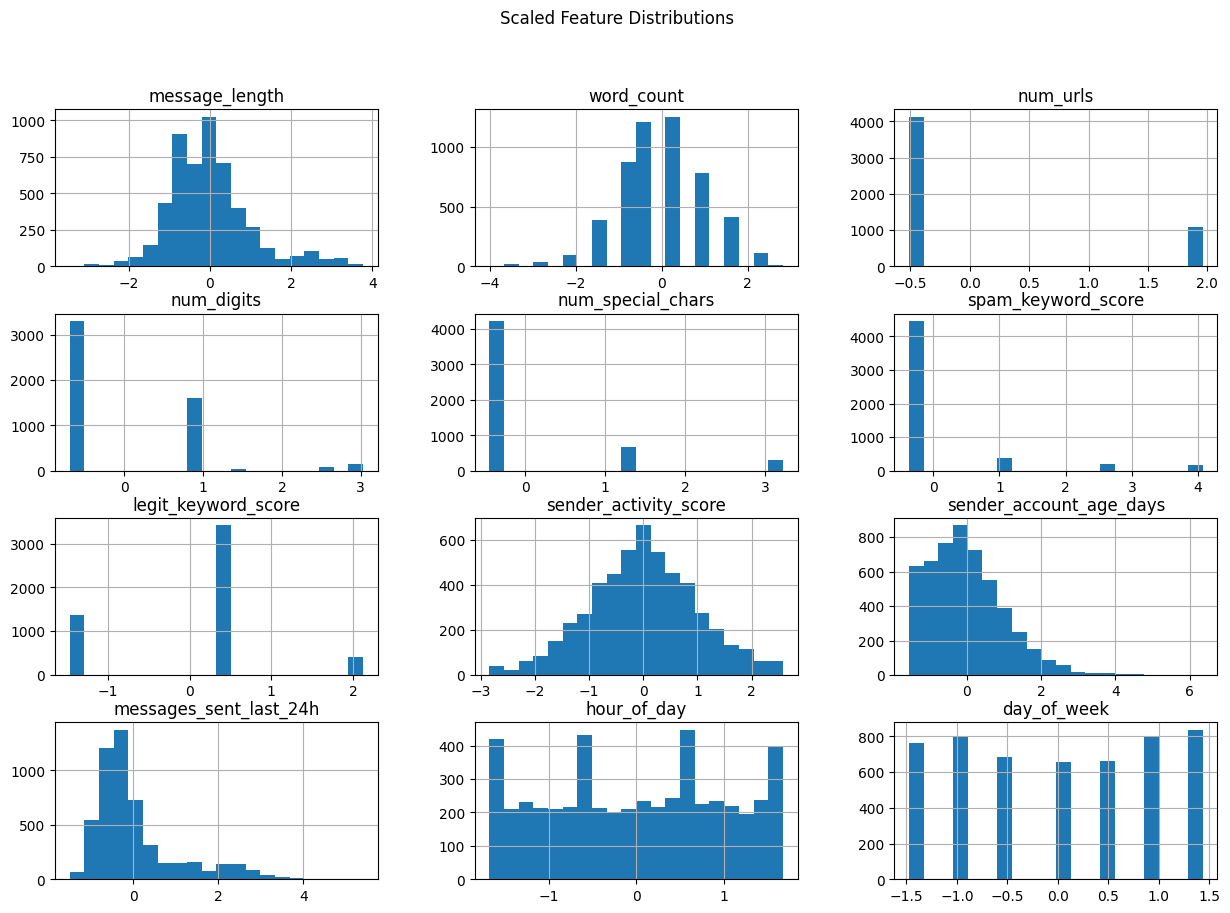

In [16]:
X_scaled.hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle("Scaled Feature Distributions")

plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [18]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (4160, 12)
X_test  : (1040, 12)
y_train : (4160,)
y_test  : (1040,)


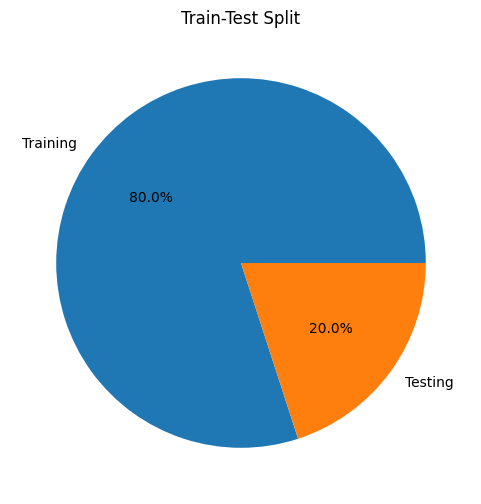

In [19]:
sizes = [
    len(X_train),
    len(X_test)
]

labels = [
    "Training",
    "Testing"
]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Train-Test Split")

plt.show()

## Conclusion

The Message Intelligence dataset was successfully analyzed and prepared for machine learning. Missing values were identified and handled using median imputation to ensure data quality. Exploratory Data Analysis (EDA) through histograms, boxplots, target distribution plots, and a correlation heatmap provided insights into feature distributions, class balance, outliers, and relationships among variables.

To improve model performance and ensure fair comparison between features, all numerical attributes were standardized using StandardScaler. Finally, the dataset was divided into training (80%) and testing (20%) sets using stratified sampling, preserving the original class distribution. The processed dataset is now ready for implementing and evaluating KNN, SVM, and Naive Bayes classifiers in the subsequent parts of the project.
